# EEGMMIDB Personalized (Subject-Dependent)

This notebook is streamlined into clear sections.
- Edit only `EXPERIMENT` in **Configuration**.
- Core logic lives in `bci_personalized_pipeline.py`.


In [132]:

# Uncomment if your environment is missing dependencies
# %pip install mne torch numpy matplotlib scikit-learn


In [133]:

from pathlib import Path
import importlib

import mne
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import RepeatedStratifiedKFold

import bci_personalized_pipeline as bp
bp = importlib.reload(bp)

discover_edf_files = bp.discover_edf_files
build_epoch_arrays = bp.build_epoch_arrays
run_holdout_split_indices = bp.run_holdout_split_indices
stratified_epoch_split_indices = bp.stratified_epoch_split_indices
fit_channel_zscore = bp.fit_channel_zscore
apply_channel_zscore = bp.apply_channel_zscore
sliding_window_augment = bp.sliding_window_augment
make_dataloaders = bp.make_dataloaders
train_one_split = bp.train_one_split

mne.set_log_level("WARNING")
print("mne:", mne.__version__)
print("pipeline train_one_split:", bp.train_one_split.__name__)


mne: 1.12.1
pipeline train_one_split: train_one_split


## Configuration


In [134]:

# Data configuration
DATA_ROOT = Path("./MNE-eegbci-data/files/eegmmidb/1.0.0")
TASK = "left_right"  # "left_right" or "hands_feet"

RUNS_BY_TASK = {
    "left_right": [4, 8, 12],
    "hands_feet": [6, 10, 14],
}
EVENT_MAP_BY_TASK = {
    "left_right": {"T1": "left_fist", "T2": "right_fist"},
    "hands_feet": {"T1": "both_fists", "T2": "both_feet"},
}

SUBJECT_IDS = list(range(1, 110))
MAX_FILES = None
L_FREQ, H_FREQ = 7.0, 30.0
TARGET_SFREQ = 128.0
TMIN, TMAX = (0.5, 3.5)
BATCH_SIZE = 32
NUM_WORKERS = 0

# Single source of truth for experiment behavior
EXPERIMENT = {
    "subject_id": 1,
    "split_mode": "run_holdout",          # "run_holdout" or "epoch_stratified"
    "holdout_test_run": 12,
    "subject_val_fraction": 0.2,
    "split_seed": 42,

    "batch_size": 32,
    "num_workers": 0,

    "use_sliding_window_aug": True,
    "aug_window_seconds": 2.0,
    "aug_step_seconds": 0.5,

    "model_size": "base",                # "small" or "base"
    "use_pretrain": False,
    "pretrain_ckpt_path": "best_eegnet_lite_subject_independent.pt",

    # Loss/stability controls
    "class_weight_mode": "balanced",     # "none" or "balanced"
    "class_weights": None,                 # explicit list like [1.0, 1.2] or None
    "learning_rate": 1e-3,
    "weight_decay": 2e-4,
    "grad_clip_norm": 1.0,                # None or float
    "train_seed": 42,
    "deterministic_training": True,

    "run_holdout_sweep": True,
    "holdout_runs": [4, 8, 12],

    "run_repeated_cv": False,
    "cv_n_splits": 5,
    "cv_n_repeats": 5,
    "cv_use_sliding_window_aug": True,
    "cv_aug_window_seconds": 2.0,
    "cv_aug_step_seconds": 0.5,

    "epochs_single": 30,
    "use_early_stopping": False,
    "patience_single": 20,
    "epochs_cv": 20,
    "use_early_stopping_cv": False,
    "patience_cv": 10,
}

BATCH_SIZE = int(EXPERIMENT.get("batch_size", BATCH_SIZE))
NUM_WORKERS = int(EXPERIMENT.get("num_workers", NUM_WORKERS))

assert DATA_ROOT.exists(), f"Missing data directory: {DATA_ROOT.resolve()}"
assert TASK in RUNS_BY_TASK

print("Data root:", DATA_ROOT.resolve())
print("Task:", TASK, "Runs:", RUNS_BY_TASK[TASK])
print("Epoch window (s):", (TMIN, TMAX), "| Target sfreq:", TARGET_SFREQ)
print("Experiment:", {
    "subject": EXPERIMENT["subject_id"],
    "split_mode": EXPERIMENT["split_mode"],
    "use_pretrain": EXPERIMENT["use_pretrain"],
    "run_repeated_cv": EXPERIMENT["run_repeated_cv"],
    "class_weight_mode": EXPERIMENT["class_weight_mode"],
    "deterministic_training": EXPERIMENT["deterministic_training"],
    "batch_size": EXPERIMENT["batch_size"],
    "lr": EXPERIMENT["learning_rate"],
})


Data root: C:\Users\Kades\Documents\MAU\AML GP\BCI\MNE-eegbci-data\files\eegmmidb\1.0.0
Task: left_right Runs: [4, 8, 12]
Epoch window (s): (0.5, 3.5) | Target sfreq: 128.0
Experiment: {'subject': 1, 'split_mode': 'run_holdout', 'use_pretrain': False, 'run_repeated_cv': False, 'class_weight_mode': 'balanced', 'deterministic_training': True, 'batch_size': 32, 'lr': 0.001}


## Build Dataset


In [135]:

edf_files = discover_edf_files(
    data_root=DATA_ROOT,
    subject_ids=SUBJECT_IDS,
    runs=RUNS_BY_TASK[TASK],
    max_files=MAX_FILES,
)

print(f"Found {len(edf_files)} EDF files for task '{TASK}'.")
print("Example file:", edf_files[0] if edf_files else "None")

X, y, subject_ids, run_ids, id_to_class, class_to_label = build_epoch_arrays(
    edf_files=edf_files,
    event_map=EVENT_MAP_BY_TASK[TASK],
    l_freq=L_FREQ,
    h_freq=H_FREQ,
    target_sfreq=TARGET_SFREQ,
    tmin=TMIN,
    tmax=TMAX,
)

print("X shape (N,1,C,T):", X.shape)
print("y shape:", y.shape)
print("Subject ids shape:", subject_ids.shape, "| unique subjects:", len(np.unique(subject_ids)))
print("Run ids shape:", run_ids.shape, "| unique runs:", sorted(np.unique(run_ids).tolist()))
print("class map (event_id -> class_index):", id_to_class)
print("class labels (class_index -> label):", class_to_label)


Found 327 EDF files for task 'left_right'.
Example file: MNE-eegbci-data\files\eegmmidb\1.0.0\S001\S001R04.edf
Processed 20/327 files
Processed 40/327 files
Processed 60/327 files
Processed 80/327 files
Processed 100/327 files
Processed 120/327 files
Processed 140/327 files
Processed 160/327 files
Processed 180/327 files
Processed 200/327 files
Processed 220/327 files
Processed 240/327 files
Processed 260/327 files
Processed 280/327 files


c:\Users\Kades\Documents\MAU\AML GP\BCI\bci_personalized_pipeline.py:124: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
c:\Users\Kades\Documents\MAU\AML GP\BCI\bci_personalized_pipeline.py:124: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)
c:\Users\Kades\Documents\MAU\AML GP\BCI\bci_personalized_pipeline.py:124: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw = mne.io.read_raw_edf(edf_path, preload=True, verbose=False)


Processed 300/327 files
Processed 320/327 files
X shape (N,1,C,T): (4917, 1, 64, 385)
y shape: (4917,)
Subject ids shape: (4917,) | unique subjects: 109
Run ids shape: (4917,) | unique runs: [4, 8, 12]
class map (event_id -> class_index): {np.int64(2): 0, np.int64(3): 1}
class labels (class_index -> label): {0: 'left_fist', 1: 'right_fist'}


## Split And Prepare Inputs


In [136]:

cfg = EXPERIMENT

split_mode = str(cfg["split_mode"])
subject_id = int(cfg["subject_id"])
holdout_run = int(cfg["holdout_test_run"])
val_fraction = float(cfg["subject_val_fraction"])
split_seed = int(cfg["split_seed"])

use_aug = bool(cfg["use_sliding_window_aug"])
aug_window_seconds = float(cfg["aug_window_seconds"])
aug_step_seconds = float(cfg["aug_step_seconds"])

subj_mask = subject_ids == subject_id
X_subj = X[subj_mask]
y_subj = y[subj_mask]
runs_subj = run_ids[subj_mask]

if split_mode == "run_holdout":
    train_idx, eval_idx = run_holdout_split_indices(runs_subj, holdout_run=holdout_run)
    split_desc = f"run_holdout_R{holdout_run:02d}"
elif split_mode == "epoch_stratified":
    train_idx, eval_idx = stratified_epoch_split_indices(y_subj, val_fraction=val_fraction, seed=split_seed)
    split_desc = f"epoch_stratified_{int(round(val_fraction * 100))}pct"
else:
    raise ValueError(f"Invalid split_mode: {split_mode}")

X_train_raw, y_train = X_subj[train_idx], y_subj[train_idx]
X_eval_raw, y_eval = X_subj[eval_idx], y_subj[eval_idx]

mean, std = fit_channel_zscore(X_train_raw)
X_train = apply_channel_zscore(X_train_raw, mean, std)
X_eval = apply_channel_zscore(X_eval_raw, mean, std)

X_train_model, y_train_model = X_train, y_train
X_eval_model, y_eval_model = X_eval, y_eval

if use_aug:
    win = int(round(aug_window_seconds * TARGET_SFREQ))
    step = int(round(aug_step_seconds * TARGET_SFREQ))
    X_train_model, y_train_model = sliding_window_augment(X_train, y_train, window_size_samples=win, step_samples=step)
    X_eval_model, y_eval_model = sliding_window_augment(X_eval, y_eval, window_size_samples=win, step_samples=step)

train_ds, eval_ds, train_loader, eval_loader = make_dataloaders(
    X_train_model,
    y_train_model,
    X_eval_model,
    y_eval_model,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

ACTIVE_PROTOCOL = f"subject_dependent_S{subject_id:03d}_{split_desc}"

print("Active protocol:", ACTIVE_PROTOCOL)
print("Subject epochs total:", len(y_subj))
print("Raw train/eval epoch counts:", len(train_idx), len(eval_idx))
print("Final train/eval sample counts:", len(train_ds), len(eval_ds))
print("Train class counts:", dict(zip(*np.unique(y_train_model, return_counts=True))))
print("Eval class counts:", dict(zip(*np.unique(y_eval_model, return_counts=True))))
if split_mode == "run_holdout":
    print("Holdout run:", holdout_run)
    print("Train runs:", sorted(np.unique(runs_subj[train_idx]).tolist()))
    print("Eval runs:", sorted(np.unique(runs_subj[eval_idx]).tolist()))
print("Batch X:", tuple(next(iter(train_loader))[0].shape))


Active protocol: subject_dependent_S001_run_holdout_R12
Subject epochs total: 45
Raw train/eval epoch counts: 30 15
Final train/eval sample counts: 90 45
Train class counts: {np.int64(0): np.int64(48), np.int64(1): np.int64(42)}
Eval class counts: {np.int64(0): np.int64(21), np.int64(1): np.int64(24)}
Holdout run: 12
Train runs: [4, 8]
Eval runs: [12]
Batch X: (32, 1, 64, 256)


## Train And Evaluate


Config: {'model_size': 'base', 'use_pretrain': False, 'class_weight_mode': 'balanced', 'lr': 0.001, 'weight_decay': 0.0002, 'run_holdout_sweep': True, 'run_repeated_cv': False}

Running holdout-run sweep...
[subject_dependent_S001_holdout_R04] class weights: [1.0, 1.0]
[subject_dependent_S001_holdout_R04] Epoch 01/30 | lr=1.00e-03 | train_loss=0.6893 train_acc=0.5222 | eval_loss=0.6969 eval_acc=0.4667 eval_bal_acc=0.5000
[subject_dependent_S001_holdout_R04] Epoch 02/30 | lr=1.00e-03 | train_loss=0.6994 train_acc=0.5556 | eval_loss=0.6972 eval_acc=0.4667 eval_bal_acc=0.5000
[subject_dependent_S001_holdout_R04] Epoch 03/30 | lr=1.00e-03 | train_loss=0.6671 train_acc=0.6222 | eval_loss=0.6975 eval_acc=0.4667 eval_bal_acc=0.5000
[subject_dependent_S001_holdout_R04] Epoch 04/30 | lr=1.00e-03 | train_loss=0.6836 train_acc=0.5778 | eval_loss=0.6977 eval_acc=0.4667 eval_bal_acc=0.5000
[subject_dependent_S001_holdout_R04] Epoch 05/30 | lr=1.00e-03 | train_loss=0.7039 train_acc=0.5556 | eval_los

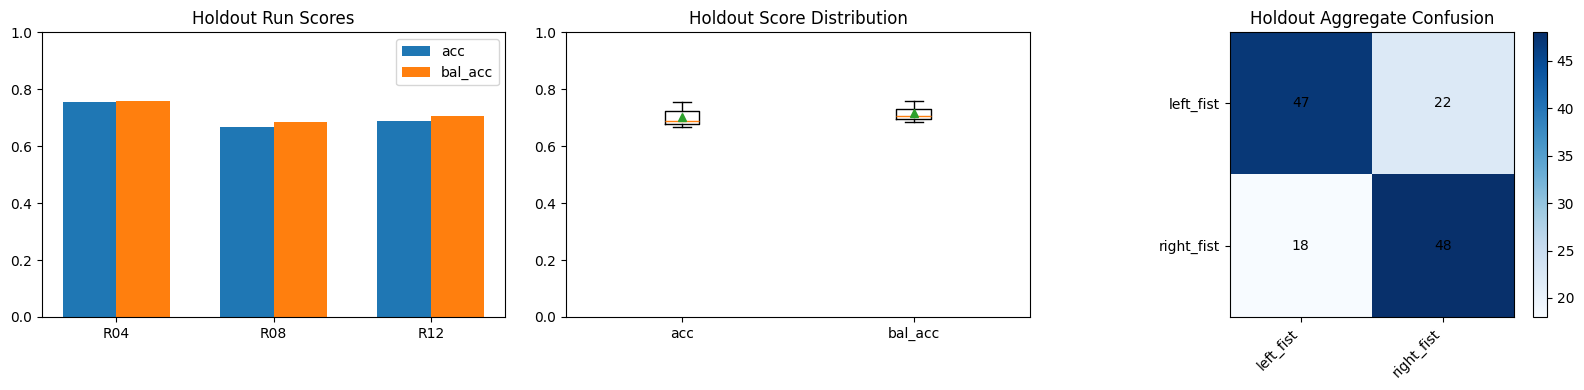

In [137]:

cfg = EXPERIMENT

model_size = str(cfg["model_size"])
use_pretrain = bool(cfg["use_pretrain"])
pretrain_ckpt = str(cfg["pretrain_ckpt_path"])
class_weight_mode = str(cfg.get("class_weight_mode", "none"))
class_weights = cfg.get("class_weights", None)
learning_rate = float(cfg.get("learning_rate", 1e-3))
weight_decay = float(cfg.get("weight_decay", 2e-4))
grad_clip_norm = cfg.get("grad_clip_norm", None)
train_seed = int(cfg.get("train_seed", 42))
deterministic_training = bool(cfg.get("deterministic_training", True))

run_holdout_sweep = bool(cfg.get("run_holdout_sweep", False))
holdout_runs = list(cfg.get("holdout_runs", [4, 8, 12]))

run_repeated_cv = bool(cfg["run_repeated_cv"])
cv_n_splits = int(cfg["cv_n_splits"])
cv_n_repeats = int(cfg["cv_n_repeats"])
cv_use_aug = bool(cfg["cv_use_sliding_window_aug"])
cv_aug_window_seconds = float(cfg["cv_aug_window_seconds"])
cv_aug_step_seconds = float(cfg["cv_aug_step_seconds"])

epochs_single = int(cfg["epochs_single"])
patience_single = int(cfg["patience_single"])
use_early_stopping = bool(cfg.get("use_early_stopping", False))
epochs_cv = int(cfg["epochs_cv"])
patience_cv = int(cfg["patience_cv"])
use_early_stopping_cv = bool(cfg.get("use_early_stopping_cv", False))

use_aug = bool(cfg["use_sliding_window_aug"])
aug_window_seconds = float(cfg["aug_window_seconds"])
aug_step_seconds = float(cfg["aug_step_seconds"])


def class_metrics_from_cm(cm: np.ndarray, labels: list[str]):
    rows = []
    for i, label in enumerate(labels):
        tp = float(cm[i, i])
        fn = float(cm[i, :].sum() - tp)
        fp = float(cm[:, i].sum() - tp)
        support = int(cm[i, :].sum())
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
        rows.append({
            "class": label,
            "support": support,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })
    return rows


def print_class_metrics(rows):
    print("Class-wise metrics")
    print(f"{'class':<16} {'support':>8} {'precision':>10} {'recall':>10} {'f1':>10}")
    for r in rows:
        print(f"{r['class']:<16} {r['support']:>8d} {r['precision']:>10.4f} {r['recall']:>10.4f} {r['f1']:>10.4f}")


def print_score_stats(name: str, arr: np.ndarray):
    arr = np.asarray(arr, dtype=np.float64)
    mean = arr.mean()
    std = arr.std(ddof=1) if len(arr) > 1 else 0.0
    ci95 = 1.96 * std / np.sqrt(len(arr)) if len(arr) > 1 else 0.0
    q25, q50, q75 = np.percentile(arr, [25, 50, 75])
    print(
        f"{name}: mean={mean:.4f} | std={std:.4f} | 95%CI=+/-{ci95:.4f} | "
        f"median={q50:.4f} | IQR=[{q25:.4f}, {q75:.4f}] | min={arr.min():.4f} | max={arr.max():.4f}"
    )


def prepare_model_inputs_from_indices(train_idx, eval_idx):
    X_train_raw, y_train = X_subj[train_idx], y_subj[train_idx]
    X_eval_raw, y_eval = X_subj[eval_idx], y_subj[eval_idx]

    mean, std = fit_channel_zscore(X_train_raw)
    X_train = apply_channel_zscore(X_train_raw, mean, std)
    X_eval = apply_channel_zscore(X_eval_raw, mean, std)

    X_train_model, y_train_model = X_train, y_train
    X_eval_model, y_eval_model = X_eval, y_eval

    if use_aug:
        win = int(round(aug_window_seconds * TARGET_SFREQ))
        step = int(round(aug_step_seconds * TARGET_SFREQ))
        X_train_model, y_train_model = sliding_window_augment(X_train, y_train, window_size_samples=win, step_samples=step)
        X_eval_model, y_eval_model = sliding_window_augment(X_eval, y_eval, window_size_samples=win, step_samples=step)

    return X_train_model, y_train_model, X_eval_model, y_eval_model


print("Config:", {
    "model_size": model_size,
    "use_pretrain": use_pretrain,
    "class_weight_mode": class_weight_mode,
    "lr": learning_rate,
    "weight_decay": weight_decay,
    "run_holdout_sweep": run_holdout_sweep,
    "run_repeated_cv": run_repeated_cv,
})

labels_master = [class_to_label.get(i, str(i)) for i in range(len(np.unique(y_subj)))]

if run_holdout_sweep:
    rows = []
    cms = []

    print("\nRunning holdout-run sweep...")
    for i, holdout_run in enumerate(holdout_runs, start=1):
        tr_idx, te_idx = run_holdout_split_indices(runs_subj, holdout_run=holdout_run)
        Xtr, ytr, Xte, yte = prepare_model_inputs_from_indices(tr_idx, te_idx)

        run_name = f"subject_dependent_S{int(cfg['subject_id']):03d}_holdout_R{holdout_run:02d}"
        out = train_one_split(
            Xtr,
            ytr,
            Xte,
            yte,
            protocol_name=run_name,
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            model_size=model_size,
            use_pretrain=use_pretrain,
            pretrain_ckpt=pretrain_ckpt,
            class_weight_mode=class_weight_mode,
            class_weights=class_weights,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            grad_clip_norm=grad_clip_norm,
            seed=train_seed + i,
            deterministic=deterministic_training,
            epochs=epochs_single,
            early_stopping_patience=patience_single,
            use_early_stopping=use_early_stopping,
            save_best=False,
        )

        cm = out["cm"]
        cms.append(cm)
        m = class_metrics_from_cm(cm, labels_master)
        hard = min(m, key=lambda x: x["recall"])

        rows.append({
            "holdout_run": holdout_run,
            "acc": out["final_eval_acc"],
            "bal_acc": out["final_eval_bal_acc"],
            "hard_class": hard["class"],
            "hard_recall": hard["recall"],
        })

        print(
            f"Holdout R{holdout_run:02d} | acc={out['final_eval_acc']:.4f} | "
            f"bal_acc={out['final_eval_bal_acc']:.4f} | worst_class={hard['class']} recall={hard['recall']:.4f}"
        )

    acc_arr = np.asarray([r["acc"] for r in rows], dtype=np.float64)
    bal_arr = np.asarray([r["bal_acc"] for r in rows], dtype=np.float64)
    cm_sum = np.sum(np.stack(cms, axis=0), axis=0)

    print("\nHoldout-run summary table")
    print(f"{'run':>6} {'acc':>10} {'bal_acc':>10} {'worst_class':>16} {'worst_recall':>14}")
    for r in rows:
        print(f"R{r['holdout_run']:02d} {r['acc']:>10.4f} {r['bal_acc']:>10.4f} {r['hard_class']:>16} {r['hard_recall']:>14.4f}")

    print("\nHoldout-run aggregate metrics")
    print_score_stats("Accuracy", acc_arr)
    print_score_stats("Balanced accuracy", bal_arr)

    print("\nHoldout aggregate confusion matrix (rows=true, cols=pred):")
    print(cm_sum)
    agg_rows = class_metrics_from_cm(cm_sum, labels_master)
    print_class_metrics(agg_rows)

    hardest = min(agg_rows, key=lambda x: x["recall"])
    print(f"\nMain struggle class (holdout aggregate): {hardest['class']} (recall={hardest['recall']:.4f}, support={hardest['support']})")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    x = np.arange(len(rows))
    axes[0].bar(x - 0.17, [r['acc'] for r in rows], width=0.34, label='acc')
    axes[0].bar(x + 0.17, [r['bal_acc'] for r in rows], width=0.34, label='bal_acc')
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f"R{r['holdout_run']:02d}" for r in rows])
    axes[0].set_ylim(0.0, 1.0)
    axes[0].set_title('Holdout Run Scores')
    axes[0].legend()

    axes[1].boxplot([acc_arr, bal_arr], tick_labels=['acc', 'bal_acc'], showmeans=True)
    axes[1].set_ylim(0.0, 1.0)
    axes[1].set_title('Holdout Score Distribution')

    im = axes[2].imshow(cm_sum, cmap='Blues')
    axes[2].set_title('Holdout Aggregate Confusion')
    axes[2].set_xticks(range(len(labels_master)))
    axes[2].set_yticks(range(len(labels_master)))
    axes[2].set_xticklabels(labels_master, rotation=45, ha='right')
    axes[2].set_yticklabels(labels_master)
    for r in range(cm_sum.shape[0]):
        for c in range(cm_sum.shape[1]):
            axes[2].text(c, r, str(int(cm_sum[r, c])), ha='center', va='center', color='black')
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    fig.tight_layout()
    plt.show()

elif not run_repeated_cv:
    result = train_one_split(
        X_train_model,
        y_train_model,
        X_eval_model,
        y_eval_model,
        protocol_name=ACTIVE_PROTOCOL,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        model_size=model_size,
        use_pretrain=use_pretrain,
        pretrain_ckpt=pretrain_ckpt,
        class_weight_mode=class_weight_mode,
        class_weights=class_weights,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        grad_clip_norm=grad_clip_norm,
        seed=train_seed,
        deterministic=deterministic_training,
        epochs=epochs_single,
        early_stopping_patience=patience_single,
        use_early_stopping=use_early_stopping,
        save_best=True,
    )

    labels = [class_to_label.get(i, str(i)) for i in range(result["cm"].shape[0])]
    class_rows = class_metrics_from_cm(result["cm"], labels)

    print("\nBest epoch:", result["best_epoch"])
    print("Final eval balanced accuracy:", f"{result['final_eval_bal_acc']:.4f}")
    print("Final eval accuracy:", f"{result['final_eval_acc']:.4f}")
    print("Checkpoint:", result["ckpt_path"])
    print("\nEval confusion matrix (rows=true, cols=pred):")
    print(result["cm"])
    print_class_metrics(class_rows)

    hardest = min(class_rows, key=lambda x: x["recall"])
    print(f"\nMain struggle class: {hardest['class']} (recall={hardest['recall']:.4f}, support={hardest['support']})")

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(result["history"]["train_acc"], label="train_acc")
    axes[0].plot(result["history"]["eval_acc"], label="eval_acc")
    axes[0].plot(result["history"]["eval_bal_acc"], label="eval_bal_acc")
    axes[0].set_title("Accuracy")
    axes[0].legend()

    axes[1].plot(result["history"]["train_loss"], label="train_loss")
    axes[1].plot(result["history"]["eval_loss"], label="eval_loss")
    axes[1].set_title("Loss")
    axes[1].legend()

    cm = result["cm"]
    im = axes[2].imshow(cm, cmap="Blues")
    axes[2].set_title("Eval Confusion Matrix")
    axes[2].set_xticks(range(len(labels)))
    axes[2].set_yticks(range(len(labels)))
    axes[2].set_xticklabels(labels, rotation=45, ha="right")
    axes[2].set_yticklabels(labels)
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            axes[2].text(c, r, str(cm[r, c]), ha="center", va="center", color="black")
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()

else:
    cv_acc = []
    cv_bal_acc = []
    cv_cms = []

    rskf = RepeatedStratifiedKFold(n_splits=cv_n_splits, n_repeats=cv_n_repeats, random_state=int(cfg["split_seed"]))

    for fold_i, (tr_idx, te_idx) in enumerate(rskf.split(X_subj, y_subj), start=1):
        Xtr_raw, ytr = X_subj[tr_idx], y_subj[tr_idx]
        Xte_raw, yte = X_subj[te_idx], y_subj[te_idx]

        mean, std = fit_channel_zscore(Xtr_raw)
        Xtr = apply_channel_zscore(Xtr_raw, mean, std)
        Xte = apply_channel_zscore(Xte_raw, mean, std)

        if cv_use_aug:
            win = int(round(cv_aug_window_seconds * TARGET_SFREQ))
            step = int(round(cv_aug_step_seconds * TARGET_SFREQ))
            Xtr, ytr = sliding_window_augment(Xtr, ytr, window_size_samples=win, step_samples=step)
            Xte, yte = sliding_window_augment(Xte, yte, window_size_samples=win, step_samples=step)

        fold_result = train_one_split(
            Xtr,
            ytr,
            Xte,
            yte,
            protocol_name=f"{ACTIVE_PROTOCOL}_cv{fold_i:02d}",
            batch_size=BATCH_SIZE,
            num_workers=NUM_WORKERS,
            model_size=model_size,
            use_pretrain=use_pretrain,
            pretrain_ckpt=pretrain_ckpt,
            class_weight_mode=class_weight_mode,
            class_weights=class_weights,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            grad_clip_norm=grad_clip_norm,
            seed=train_seed + fold_i,
            deterministic=deterministic_training,
            epochs=epochs_cv,
            early_stopping_patience=patience_cv,
            use_early_stopping=use_early_stopping_cv,
            save_best=False,
        )

        cv_acc.append(fold_result["final_eval_acc"])
        cv_bal_acc.append(fold_result["final_eval_bal_acc"])
        cv_cms.append(fold_result["cm"])

        print(
            f"CV fold {fold_i:02d} done | "
            f"acc={fold_result['final_eval_acc']:.4f} | "
            f"bal_acc={fold_result['final_eval_bal_acc']:.4f}"
        )

    cv_acc = np.asarray(cv_acc, dtype=np.float64)
    cv_bal_acc = np.asarray(cv_bal_acc, dtype=np.float64)
    cm_sum = np.sum(np.stack(cv_cms, axis=0), axis=0)

    labels = [class_to_label.get(i, str(i)) for i in range(cm_sum.shape[0])]
    class_rows = class_metrics_from_cm(cm_sum, labels)

    print("\nRepeated CV summary")
    print("Folds:", len(cv_acc))
    print_score_stats("Accuracy", cv_acc)
    print_score_stats("Balanced accuracy", cv_bal_acc)

    print("\nAggregated confusion matrix over all CV folds (rows=true, cols=pred):")
    print(cm_sum)
    print_class_metrics(class_rows)

    hardest = min(class_rows, key=lambda x: x["recall"])
    print(f"\nMain struggle class (CV aggregate): {hardest['class']} (recall={hardest['recall']:.4f}, support={hardest['support']})")

    worst_n = min(3, len(cv_bal_acc))
    worst_idx = np.argsort(cv_bal_acc)[:worst_n]
    print("\nWorst folds by balanced accuracy:")
    for idx in worst_idx:
        print(f"  fold={idx+1:02d} | acc={cv_acc[idx]:.4f} | bal_acc={cv_bal_acc[idx]:.4f}")

    fold_ids = np.arange(1, len(cv_acc) + 1)
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(fold_ids, cv_acc, marker="o", label="fold_acc")
    axes[0].plot(fold_ids, cv_bal_acc, marker="o", label="fold_bal_acc")
    axes[0].axhline(cv_acc.mean(), linestyle="--", linewidth=1, label=f"acc_mean={cv_acc.mean():.3f}")
    axes[0].axhline(cv_bal_acc.mean(), linestyle="--", linewidth=1, label=f"bal_acc_mean={cv_bal_acc.mean():.3f}")
    axes[0].set_title("CV Fold Metrics")
    axes[0].set_xlabel("Fold")
    axes[0].set_ylabel("Score")
    axes[0].set_ylim(0.0, 1.0)
    axes[0].set_xticks(fold_ids)
    axes[0].legend()

    axes[1].boxplot([cv_acc, cv_bal_acc], tick_labels=["acc", "bal_acc"], showmeans=True)
    axes[1].set_title("CV Score Distribution")
    axes[1].set_ylabel("Score")
    axes[1].set_ylim(0.0, 1.0)

    im = axes[2].imshow(cm_sum, cmap="Blues")
    axes[2].set_title("CV Aggregate Confusion")
    axes[2].set_xticks(range(len(labels)))
    axes[2].set_yticks(range(len(labels)))
    axes[2].set_xticklabels(labels, rotation=45, ha="right")
    axes[2].set_yticklabels(labels)
    for r in range(cm_sum.shape[0]):
        for c in range(cm_sum.shape[1]):
            axes[2].text(c, r, str(int(cm_sum[r, c])), ha="center", va="center", color="black")
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    fig.tight_layout()
    plt.show()


## Auto Config Sweep
Run multiple config variants automatically across holdout runs and rank them.


In [138]:
# Adaptive auto-config sweep (dynamic budget allocation)
# Promotes promising configs to longer runs automatically.

import numpy as np
import pandas as pd

base_cfg = dict(EXPERIMENT)

# Include a stable anchor from your strongest manual direction.
CANDIDATES = [
    {
        "name": "anchor_manual_base",
        "train_overrides": {
            "model_size": "base",
            "learning_rate": 1e-3,
            "weight_decay": 2e-4,
            "class_weight_mode": "balanced",
            "use_pretrain": False,
        },
        "data_overrides": {
            "normalize_channels": True,
            "use_augmentation": False,
        },
    },
    {
        "name": "small_aug",
        "train_overrides": {
            "model_size": "small",
            "learning_rate": 8e-4,
            "weight_decay": 2e-4,
            "class_weight_mode": "balanced",
            "use_pretrain": False,
        },
        "data_overrides": {
            "normalize_channels": True,
            "use_augmentation": True,
            "aug_window_seconds": 2.5,
            "aug_step_seconds": 0.5,
        },
    },
    {
        "name": "base_no_aug",
        "train_overrides": {
            "model_size": "base",
            "learning_rate": 1e-3,
            "weight_decay": 2e-4,
            "class_weight_mode": "balanced",
            "use_pretrain": False,
        },
        "data_overrides": {
            "normalize_channels": True,
            "use_augmentation": False,
        },
    },
    {
        "name": "small_low_lr",
        "train_overrides": {
            "model_size": "small",
            "learning_rate": 5e-4,
            "weight_decay": 5e-4,
            "class_weight_mode": "balanced",
            "use_pretrain": False,
        },
        "data_overrides": {
            "normalize_channels": True,
            "use_augmentation": True,
            "aug_window_seconds": 2.0,
            "aug_step_seconds": 0.5,
        },
    },
]

adaptive_result = bp.run_adaptive_holdout_sweep(
    X_subj,
    y_subj,
    runs_subj,
    holdout_runs=list(base_cfg.get("holdout_runs", [4, 8, 12])),
    candidate_configs=CANDIDATES,
    train_kwargs={
        "batch_size": int(base_cfg.get("batch_size", 32)),
        "num_workers": int(base_cfg.get("num_workers", 0)),
        "model_size": str(base_cfg.get("model_size", "small")),
        "use_pretrain": bool(base_cfg.get("use_pretrain", False)),
        "pretrain_ckpt": str(base_cfg.get("pretrain_ckpt", "best_eegnet_lite_subject_independent.pt")),
        "class_weight_mode": str(base_cfg.get("class_weight_mode", "balanced")),
        "learning_rate": float(base_cfg.get("learning_rate", 1e-3)),
        "weight_decay": float(base_cfg.get("weight_decay", 2e-4)),
        "grad_clip_norm": base_cfg.get("grad_clip_norm", None),
    },
    data_kwargs={
        "normalize_channels": bool(base_cfg.get("normalize_channels", True)),
        "use_augmentation": bool(base_cfg.get("use_augmentation", False)),
        "augment_eval": False,  # keep holdout eval untouched
        "aug_window_seconds": float(base_cfg.get("aug_window_seconds", 2.0)),
        "aug_step_seconds": float(base_cfg.get("aug_step_seconds", 0.5)),
        "target_sfreq": float(TARGET_SFREQ),
    },
    initial_epochs=20,
    max_epochs=80,
    max_stages=3,
    keep_ratio=0.5,
    min_keep=2,
    growth_factor=1.8,
    min_stage_improvement=0.003,
    early_stopping_patience=8,
    patience_growth=1.35,
    use_early_stopping=True,
    deterministic=bool(base_cfg.get("deterministic_training", True)),
    base_seed=int(base_cfg.get("seed", 42)),
    seeds_per_candidate=2,
)

leader_rows = []
for row in adaptive_result["leaderboard"]:
    leader_rows.append({
        "name": row["name"],
        "stage": int(row["stage"]),
        "epochs": int(row["epochs"]),
        "patience": int(row["patience"]),
        "seeds_per_candidate": int(row.get("seeds_per_candidate", 1)),
        "bal_mean": float(row["bal_mean"]),
        "bal_std": float(row["bal_std"]),
        "bal_worst": float(row["bal_worst"]),
        "improvement": float(row["improvement"]) if np.isfinite(row["improvement"]) else np.nan,
        "run_scores": [round(float(x), 4) for x in row["run_bal_acc"]],
    })

leader_df = pd.DataFrame(leader_rows)
if len(leader_df) == 0:
    print("Adaptive sweep produced no rows.")
else:
    print("\nAdaptive leaderboard (best rows first):")
    display(leader_df.head(12))

best = adaptive_result.get("best", None)
if best is not None:
    print("\nBest adaptive result:")
    print({
        "name": best["name"],
        "stage": int(best["stage"]),
        "epochs": int(best["epochs"]),
        "seeds_per_candidate": int(best.get("seeds_per_candidate", 1)),
        "bal_mean": round(float(best["bal_mean"]), 4),
        "bal_std": round(float(best["bal_std"]), 4),
        "bal_worst": round(float(best["bal_worst"]), 4),
    })




[adaptive] Stage 1/3 | active=4
[adaptive_anchor_manual_base_S1_R04_K1] class weights: [1.0, 1.0]
[adaptive_anchor_manual_base_S1_R04_K1] Epoch 01/20 | lr=1.00e-03 | train_loss=0.6888 train_acc=0.6000 | eval_loss=0.6915 eval_acc=0.4000 eval_bal_acc=0.3839
[adaptive_anchor_manual_base_S1_R04_K1] Epoch 02/20 | lr=1.00e-03 | train_loss=0.6841 train_acc=0.6000 | eval_loss=0.6911 eval_acc=0.4000 eval_bal_acc=0.3839
[adaptive_anchor_manual_base_S1_R04_K1] Epoch 03/20 | lr=1.00e-03 | train_loss=0.7085 train_acc=0.4000 | eval_loss=0.6905 eval_acc=0.4667 eval_bal_acc=0.4554
[adaptive_anchor_manual_base_S1_R04_K1] Epoch 04/20 | lr=1.00e-03 | train_loss=0.6829 train_acc=0.5667 | eval_loss=0.6899 eval_acc=0.6000 eval_bal_acc=0.5982
[adaptive_anchor_manual_base_S1_R04_K1] Epoch 05/20 | lr=1.00e-03 | train_loss=0.6547 train_acc=0.5667 | eval_loss=0.6892 eval_acc=0.6000 eval_bal_acc=0.5982
[adaptive_anchor_manual_base_S1_R04_K1] Epoch 06/20 | lr=1.00e-03 | train_loss=0.6079 train_acc=0.8000 | eval_l

,name,stage,epochs,patience,seeds_per_candidate,bal_mean,bal_std,bal_worst,improvement,run_scores
0,small_low_lr,1,20,8,2,0.645833,0.008418,0.633929,NaN,"[0.6518, 0.6339, 0.6518]"
1,base_no_aug,1,20,8,2,0.599702,0.029463,0.558036,NaN,"[0.6205, 0.6205, 0.558]"
2,base_no_aug,2,36,11,2,0.568452,0.101954,0.473214,-0.031250,"[0.7098, 0.4732, 0.5223]"
3,small_low_lr,2,36,11,2,0.565476,0.029687,0.540179,-0.080357,"[0.6071, 0.5491, 0.5402]"
4,small_aug,1,20,8,2,0.535714,0.029161,0.500000,NaN,"[0.5714, 0.5357, 0.5]"
5,anchor_manual_base,1,20,8,2,0.531250,0.038056,0.500000,NaN,"[0.5848, 0.5089, 0.5]"



Best adaptive result:
{'name': 'small_low_lr', 'stage': 1, 'epochs': 20, 'seeds_per_candidate': 2, 'bal_mean': 0.6458, 'bal_std': 0.0084, 'bal_worst': 0.6339}


## Winner Neighborhood Sweep
Focused, fixed-budget sweep around the current best config (`small_low_lr`).


In [139]:
# Winner-neighborhood sweep (fixed budget, no stage growth)
# Goal: tune around small_low_lr without overfitting from long schedules.

import numpy as np
import pandas as pd

base_cfg = dict(EXPERIMENT)

# Build compact neighborhood around the winner.
lrs = [3e-4, 5e-4, 7e-4]
wds = [2e-4, 5e-4, 1e-3]

winner_candidates = []

# Augmented variants (train-only augmentation; eval untouched)
for lr in lrs:
    for wd in wds:
        winner_candidates.append({
            "name": f"win_aug25_lr{lr:.0e}_wd{wd:.0e}",
            "train_overrides": {
                "model_size": "small",
                "learning_rate": lr,
                "weight_decay": wd,
                "class_weight_mode": "balanced",
                "use_pretrain": False,
            },
            "data_overrides": {
                "normalize_channels": True,
                "use_augmentation": True,
                "augment_eval": False,
                "aug_window_seconds": 2.5,
                "aug_step_seconds": 0.5,
            },
        })

# Two no-augmentation controls
winner_candidates.extend([
    {
        "name": "win_noaug_lr5e-4_wd5e-4",
        "train_overrides": {
            "model_size": "small",
            "learning_rate": 5e-4,
            "weight_decay": 5e-4,
            "class_weight_mode": "balanced",
            "use_pretrain": False,
        },
        "data_overrides": {
            "normalize_channels": True,
            "use_augmentation": False,
            "augment_eval": False,
        },
    },
    {
        "name": "win_noaug_lr7e-4_wd2e-4",
        "train_overrides": {
            "model_size": "small",
            "learning_rate": 7e-4,
            "weight_decay": 2e-4,
            "class_weight_mode": "balanced",
            "use_pretrain": False,
        },
        "data_overrides": {
            "normalize_channels": True,
            "use_augmentation": False,
            "augment_eval": False,
        },
    },
])

# Larger-window augmentation controls
winner_candidates.extend([
    {
        "name": "win_aug30_lr5e-4_wd5e-4",
        "train_overrides": {
            "model_size": "small",
            "learning_rate": 5e-4,
            "weight_decay": 5e-4,
            "class_weight_mode": "balanced",
            "use_pretrain": False,
        },
        "data_overrides": {
            "normalize_channels": True,
            "use_augmentation": True,
            "augment_eval": False,
            "aug_window_seconds": 3.0,
            "aug_step_seconds": 0.5,
        },
    },
    {
        "name": "win_aug30_lr7e-4_wd2e-4",
        "train_overrides": {
            "model_size": "small",
            "learning_rate": 7e-4,
            "weight_decay": 2e-4,
            "class_weight_mode": "balanced",
            "use_pretrain": False,
        },
        "data_overrides": {
            "normalize_channels": True,
            "use_augmentation": True,
            "augment_eval": False,
            "aug_window_seconds": 3.0,
            "aug_step_seconds": 0.5,
        },
    },
])

winner_result = bp.run_adaptive_holdout_sweep(
    X_subj,
    y_subj,
    runs_subj,
    holdout_runs=list(base_cfg.get("holdout_runs", [4, 8, 12])),
    candidate_configs=winner_candidates,
    train_kwargs={
        "batch_size": int(base_cfg.get("batch_size", 32)),
        "num_workers": int(base_cfg.get("num_workers", 0)),
        "model_size": "small",
        "use_pretrain": False,
        "pretrain_ckpt": str(base_cfg.get("pretrain_ckpt", "best_eegnet_lite_subject_independent.pt")),
        "class_weight_mode": "balanced",
        "learning_rate": 5e-4,
        "weight_decay": 5e-4,
        "grad_clip_norm": base_cfg.get("grad_clip_norm", None),
    },
    data_kwargs={
        "normalize_channels": bool(base_cfg.get("normalize_channels", True)),
        "use_augmentation": True,
        "augment_eval": False,
        "aug_window_seconds": 2.5,
        "aug_step_seconds": 0.5,
        "target_sfreq": float(TARGET_SFREQ),
    },
    initial_epochs=20,
    max_epochs=20,
    max_stages=1,
    keep_ratio=1.0,
    min_keep=1,
    growth_factor=1.0,
    min_stage_improvement=0.0,
    early_stopping_patience=8,
    patience_growth=1.0,
    use_early_stopping=True,
    deterministic=bool(base_cfg.get("deterministic_training", True)),
    base_seed=int(base_cfg.get("seed", 42)),
    seeds_per_candidate=2,
)

rows = []
for row in winner_result["leaderboard"]:
    rows.append({
        "name": row["name"],
        "bal_mean": float(row["bal_mean"]),
        "bal_std": float(row["bal_std"]),
        "bal_worst": float(row["bal_worst"]),
        "run_scores": [round(float(x), 4) for x in row["run_bal_acc"]],
    })

winner_df = pd.DataFrame(rows).sort_values("bal_mean", ascending=False).reset_index(drop=True)
print("Winner-neighborhood leaderboard:")
display(winner_df.head(15))

best = winner_result.get("best")
if best is not None:
    print("\nBest neighborhood config:")
    print({
        "name": best["name"],
        "bal_mean": round(float(best["bal_mean"]), 4),
        "bal_std": round(float(best["bal_std"]), 4),
        "bal_worst": round(float(best["bal_worst"]), 4),
    })




[adaptive] Stage 1/1 | active=13
[adaptive_win_aug25_lr3e-04_wd2e-04_S1_R04_K1] class weights: [1.0, 1.0]
[adaptive_win_aug25_lr3e-04_wd2e-04_S1_R04_K1] Epoch 01/20 | lr=3.00e-04 | train_loss=0.7082 train_acc=0.4667 | eval_loss=0.6950 eval_acc=0.4667 eval_bal_acc=0.5000
[adaptive_win_aug25_lr3e-04_wd2e-04_S1_R04_K1] Epoch 02/20 | lr=3.00e-04 | train_loss=0.7030 train_acc=0.4833 | eval_loss=0.6947 eval_acc=0.4667 eval_bal_acc=0.5000
[adaptive_win_aug25_lr3e-04_wd2e-04_S1_R04_K1] Epoch 03/20 | lr=3.00e-04 | train_loss=0.6851 train_acc=0.5500 | eval_loss=0.6942 eval_acc=0.4667 eval_bal_acc=0.5000
[adaptive_win_aug25_lr3e-04_wd2e-04_S1_R04_K1] Epoch 04/20 | lr=3.00e-04 | train_loss=0.7007 train_acc=0.5333 | eval_loss=0.6934 eval_acc=0.4667 eval_bal_acc=0.5000
[adaptive_win_aug25_lr3e-04_wd2e-04_S1_R04_K1] Epoch 05/20 | lr=3.00e-04 | train_loss=0.6732 train_acc=0.5833 | eval_loss=0.6922 eval_acc=0.4667 eval_bal_acc=0.5000
[adaptive_win_aug25_lr3e-04_wd2e-04_S1_R04_K1] Epoch 06/20 | lr=1.50

,name,bal_mean,bal_std,bal_worst,run_scores
0,win_aug25_lr5e-04_wd1e-03,0.601190,0.034452,0.553571,"[0.6161, 0.6339, 0.5536]"
1,win_aug25_lr3e-04_wd2e-04,0.581845,0.052612,0.544643,"[0.6562, 0.5446, 0.5446]"
2,win_aug25_lr5e-04_wd2e-04,0.578869,0.061247,0.513393,"[0.5134, 0.5625, 0.6607]"
3,win_aug25_lr7e-04_wd2e-04,0.563988,0.048128,0.500000,"[0.6161, 0.5, 0.5759]"
4,win_aug25_lr7e-04_wd1e-03,0.555060,0.017226,0.531250,"[0.5312, 0.5625, 0.5714]"
5,win_aug25_lr7e-04_wd5e-04,0.546131,0.087507,0.437500,"[0.6518, 0.4375, 0.5491]"
6,win_noaug_lr7e-4_wd2e-4,0.541667,0.058926,0.500000,"[0.5, 0.5, 0.625]"
7,win_aug25_lr3e-04_wd1e-03,0.538690,0.047573,0.473214,"[0.5848, 0.558, 0.4732]"
8,win_aug25_lr3e-04_wd5e-04,0.535714,0.029161,0.500000,"[0.5714, 0.5357, 0.5]"
9,win_aug30_lr5e-4_wd5e-4,0.531250,0.023902,0.500000,"[0.5, 0.558, 0.5357]"



Best neighborhood config:
{'name': 'win_aug25_lr5e-04_wd1e-03', 'bal_mean': 0.6012, 'bal_std': 0.0345, 'bal_worst': 0.5536}
